# Error Analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [2]:
results = pd.read_csv("../outputs/predictions/final_xgb_bayesian_predictions.csv")

results["timestamp"] = pd.to_datetime(results["timestamp"])

results.head()

,timestamp,price,prediction,absolute_error
0,2026-01-01 00:00:00,58.28,49.071453,9.208547
1,2026-01-01 01:00:00,42.40,25.857014,16.542986
2,2026-01-01 02:00:00,19.57,14.999723,4.570278
3,2026-01-01 03:00:00,6.29,13.930622,7.640622
4,2026-01-01 04:00:00,3.09,14.277108,11.187108


In [3]:
mae = mean_absolute_error(results["price"], results["prediction"])

print(f"Final model MAE: {mae:.3f}")

Final model MAE: 9.593


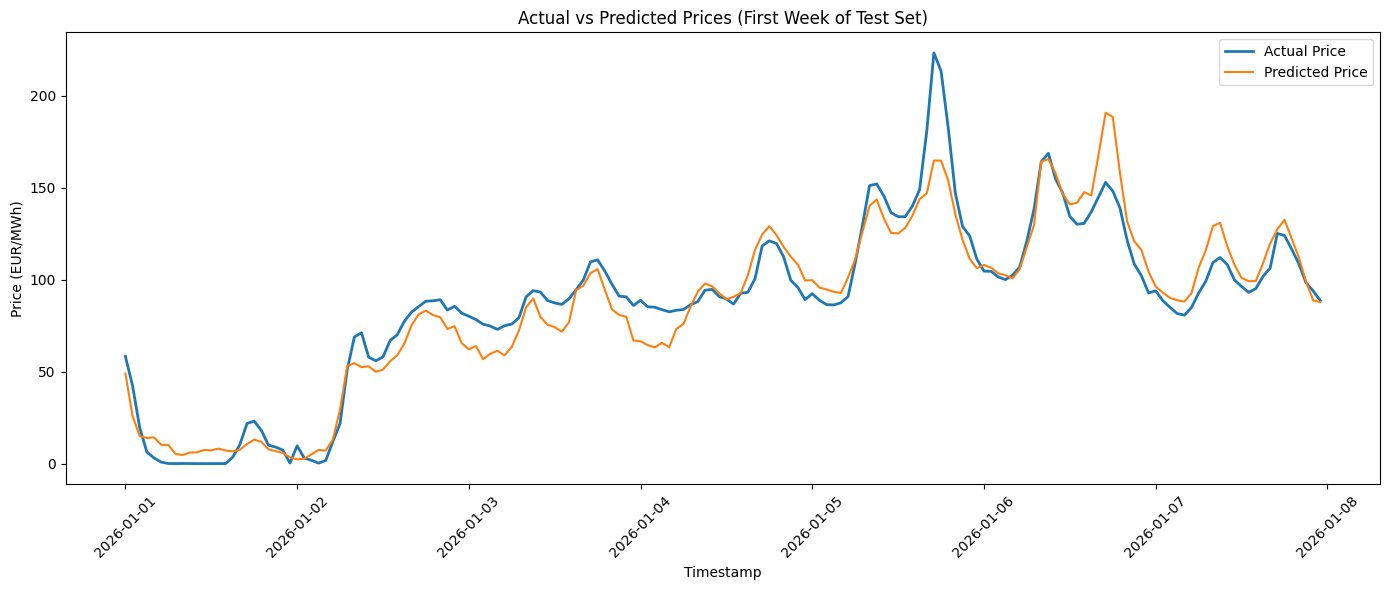

In [4]:
plot_data = results[
    (results["timestamp"] >= "2026-01-01") &
    (results["timestamp"] < "2026-01-08")
].copy()

plt.figure(figsize=(14, 6))

plt.plot(plot_data["timestamp"], plot_data["price"], label="Actual Price", linewidth=2)
plt.plot(plot_data["timestamp"], plot_data["prediction"], label="Predicted Price")

plt.title("Actual vs Predicted Prices (First Week of Test Set)")
plt.xlabel("Timestamp")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

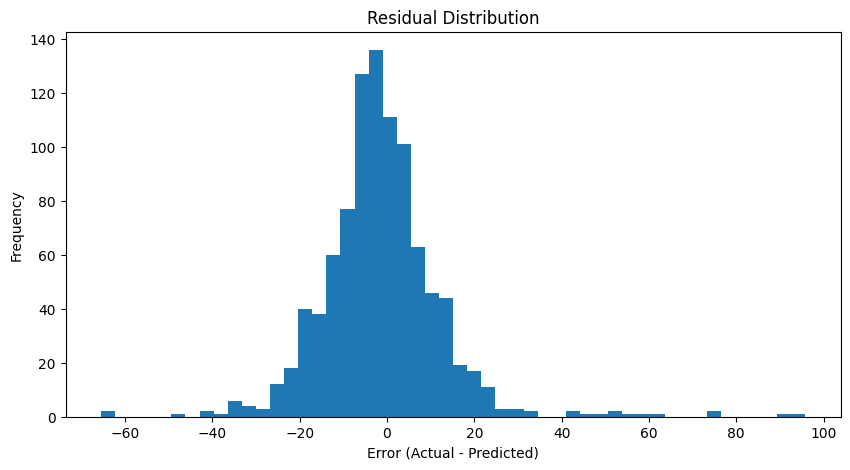

In [5]:
results["residual"] = results["price"] - results["prediction"]

plt.figure(figsize=(10, 5))

plt.hist(results["residual"], bins=50)

plt.title("Residual Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()

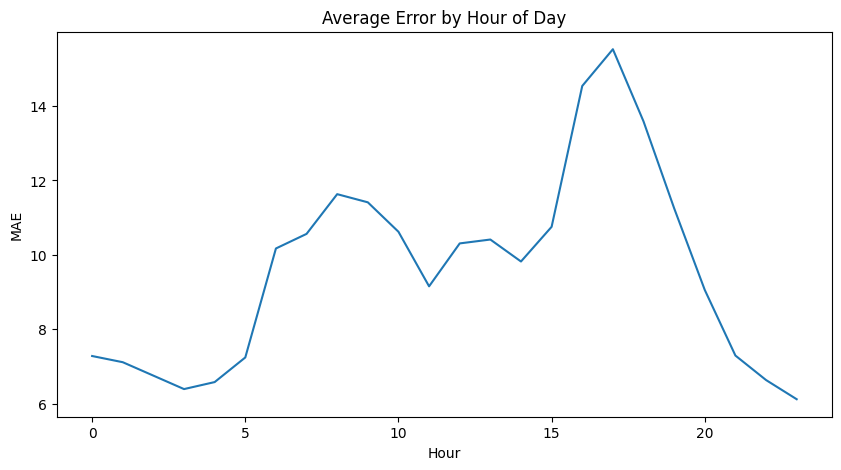

In [6]:
results["hour"] = results["timestamp"].dt.hour

hourly_error = results.groupby("hour")["absolute_error"].mean()

plt.figure(figsize=(10, 5))

hourly_error.plot()

plt.title("Average Error by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("MAE")

plt.show()

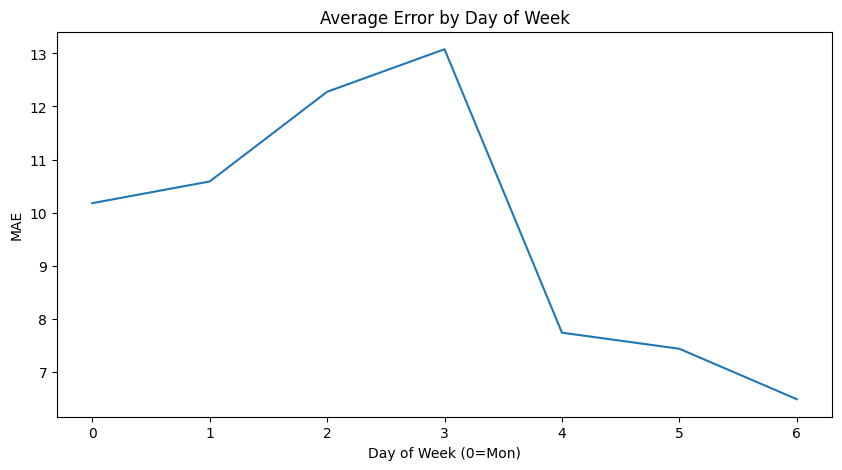

In [7]:
results["dayofweek"] = results["timestamp"].dt.dayofweek

dow_error = results.groupby("dayofweek")["absolute_error"].mean()

plt.figure(figsize=(10, 5))

dow_error.plot()

plt.title("Average Error by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("MAE")

plt.show()

In [8]:
worst_cases = results.sort_values(by="absolute_error", ascending=False).head(10)

worst_cases

,timestamp,price,prediction,absolute_error,residual,hour,dayofweek
182,2026-01-08 14:00:00,264.59,168.73671,95.853290,95.85329,14,3
183,2026-01-08 15:00:00,264.42,173.80244,90.617556,90.61756,15,3
184,2026-01-08 16:00:00,259.49,184.56917,74.920832,74.92083,16,3
181,2026-01-08 13:00:00,236.22,162.22368,73.996321,73.99632,13,3
632,2026-01-27 08:00:00,176.64,242.15970,65.519698,-65.51970,8,1
631,2026-01-27 07:00:00,159.88,224.94276,65.062764,-65.06276,7,1
180,2026-01-08 12:00:00,220.27,157.79842,62.471584,62.47158,12,3
113,2026-01-05 17:00:00,223.43,164.87135,58.558647,58.55865,17,0
185,2026-01-08 17:00:00,233.85,178.27126,55.578745,55.57874,17,3
462,2026-01-20 06:00:00,190.11,137.65753,52.452468,52.45247,6,1


## Error Analysis Summary

The model achieves a test MAE of 9.593, indicating strong overall performance. However, several patterns are observed in the prediction errors:

### 1. Time-of-day errors
The highest errors occur during the afternoon hours (approximately 13:00–18:00). These periods often correspond to peak demand and higher price volatility.

### 2. Difficulty during price spikes
The model struggles significantly during extreme price spikes. In several cases, the actual price exceeded 250 €/MWh, while the model predicted values around 160–180 €/MWh, leading to large errors.

### 3. Systematic underestimation
During high-price events, the model tends to underestimate prices. This suggests that extreme market conditions are not fully captured by the current feature set.

### 4. Overestimation in some cases
In a few instances, the model overestimates prices during moderate conditions, indicating sensitivity to recent patterns.

### 5. Overall conclusion
The model performs well under normal conditions but has difficulty capturing sudden and extreme price movements. This is expected, as such spikes are driven by complex and often unpredictable factors in electricity markets.